In [1]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import importlib
from torchinfo import summary
import time
import sys
import pandas as pd
import scipy


sys.path.append('..')
import plot_settings
plot_settings.apply()
colors = plot_settings.colors()

# Importing data

In [118]:
DT = 2

In [119]:

def read_data(file_name):
    df = pd.read_csv(
        f"Multi_data_bin/{file_name}.txt",
        delim_whitespace=True,
        comment="%",
        header=None
    )

    df.columns = ['u_par','C','t','E_cell (V)','I_cell (A)','Rx_cell (N)','u_cell (m)','E_ocv_cell (V)']

    # Sort by time within each batch
    df = df.sort_values(["C", "t"])
    return df



path = f'3103_data_u0_80p'

data = read_data(path)

#rename columns
data.columns = ['u_par','C','t','V_t','I','Rx','u','ocv']

data['u'] = data['u'] * -1e6
data['Rx'] = data['Rx'] * -1e-6
data['I'] = data['I'] * -1
data['eta'] = data['V_t'] - data['ocv']


/var/folders/cc/g7htxfj57sq65d7g1185yzwr0000gn/T/ipykernel_84932/4212404441.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


In [ ]:
# Add numeric trajectory id for each unique (C, u_par) pair
data['trajectory'] = data.groupby(['C', 'u_par'], sort=True).ngroup()

# Optional lookup table (one row per trajectory)
trajectory_lookup = (
    data[['C', 'u_par', 'trajectory']]
    .drop_duplicates()
    .sort_values('trajectory')
    .reset_index(drop=True)
)

print(trajectory_lookup)
print(f"Number of trajectories: {trajectory_lookup['trajectory'].nunique()}")

      C  u_par  trajectory
0   0.5      0           0
1   0.6      0           1
2   0.7      0           2
3   0.8      0           3
4   0.9      0           4
5   1.0      0           5
6   1.1      0           6
7   1.2      0           7
8   1.3      0           8
9   1.4      0           9
10  1.5      0          10
11  1.6      0          11
12  1.7      0          12
13  1.8      0          13
14  1.9      0          14
15  2.0      0          15
16  2.1      0          16
17  2.2      0          17
18  2.3      0          18
19  2.4      0          19
20  2.5      0          20
21  2.6      0          21
22  2.7      0          22
23  2.8      0          23
24  2.9      0          24
25  3.0      0          25
26  3.1      0          26
27  3.2      0          27
28  3.3      0          28
29  3.4      0          29
30  3.5      0          30
31  3.6      0          31
32  3.7      0          32
33  3.8      0          33
34  3.9      0          34
35  4.0      0          35
3

In [127]:
# # Add a trajectory column (reuse existing IDs if already available)
# if 'trajectory_id' in data.columns:
# 	data['trajectory'] = data['trajectory_id']
# else:
# 	data['trajectory'] = data.groupby(['C'], sort=True).ngroup()

# Add finite-difference columns with the same length as `data`
N_trajs = len(data['trajectory'].unique())

test_inds = data['trajectory'] >= int(N_trajs * 0.8)

print(test_inds.sum(), 'test samples')

y = np.zeros((len(data),2))
print(len(data[['V_t']].values))
traj_len0 = 0

for traj_ids in range(0, N_trajs):
    print(f'{traj_ids} \t {traj_len0} \t {traj_len0 + len(data[data['trajectory'] == traj_ids])} \t {len(data[data['trajectory'] == traj_ids-1]) - len(data[data['trajectory'] == traj_ids])}')
    traj_len1 = traj_len0 + len(data[data['trajectory'] == traj_ids]) 
    y[traj_len0:traj_len1 - 1,0] = np.diff(data['V_t'][data['trajectory'] == traj_ids].values) / DT
    y[traj_len1 - 1,0] = np.diff(data['V_t'][data['trajectory'] == traj_ids].values)[-1] / DT

    y[traj_len0:traj_len1-1,1] = np.diff(data['Rx'][data['trajectory'] == traj_ids].values) / DT
    y[traj_len1 - 1,1] = np.diff(data['Rx'][data['trajectory'] == traj_ids].values)[-1] / DT

    traj_len0 = traj_len1

data['dV_t'] = y[:,0]
data['dRx'] = y[:,1]

# dV = np.diff(data['V_t'].to_numpy())[:-1] / DT
# dRx = np.diff(data['Rx'].to_numpy())[:-1] / DT

# if len(dV) > 0:

#     dV = np.append(dV, dV[-1])
#     dRx = np.append(dRx, dRx[-1])
# else:
#     dV = np.array([0.0])
#     dRx = np.array([0.0])

# if dV.max() > 0.1:
#     print("Warning: Large dV value detected.")
# if dRx.max() > 10:
#     print("Warning: Large dRx value detected.")

idx_test = 10000 
print(np.argmax(data['dV_t'][:idx_test]), np.max(data['dV_t'][:idx_test]))
print(np.argmax(data['dRx'][:idx_test]), np.max(data['dRx'][:idx_test]))
print(len(data['dV_t']))

display(data)

5418 test samples
61573
0 	 0 	 1801 	 -1801
1 	 1801 	 3602 	 0
2 	 3602 	 9005 	 -3602
3 	 9005 	 10806 	 3602
4 	 10806 	 14408 	 -1801
5 	 14408 	 17854 	 156
6 	 17854 	 19409 	 1891
7 	 19409 	 22253 	 -1289
8 	 22253 	 24861 	 236
9 	 24861 	 27275 	 194
10 	 27275 	 28394 	 1295
11 	 28394 	 30482 	 -969
12 	 30482 	 32438 	 132
13 	 32438 	 34280 	 114
14 	 34280 	 36012 	 110
15 	 36012 	 37650 	 94
16 	 37650 	 38426 	 862
17 	 38426 	 39902 	 -700
18 	 39902 	 41304 	 74
19 	 41304 	 42640 	 66
20 	 42640 	 43920 	 56
21 	 43920 	 44532 	 668
22 	 44532 	 45704 	 -560
23 	 45704 	 46267 	 609
24 	 46267 	 47887 	 -1057
25 	 47887 	 48406 	 1101
26 	 48406 	 49404 	 -479
27 	 49404 	 50368 	 34
28 	 50368 	 51294 	 38
29 	 51294 	 51741 	 479
30 	 51741 	 52609 	 -421
31 	 52609 	 53445 	 32
32 	 53445 	 54255 	 26
33 	 54255 	 55039 	 26
34 	 55039 	 55419 	 404
35 	 55419 	 56155 	 -356
36 	 56155 	 56869 	 22
37 	 56869 	 57561 	 22
38 	 57561 	 58235 	 18
39 	 58235 	 58

,u_par,C,t,V_t,I,Rx,u,ocv,eta,trajectory,dV_t,dRx
55492,0,0.5,0,4.304322,2.489108,0.000677,-0.0,4.324999,-0.020677,0,-0.005679,-0.106974
55493,0,0.5,2,4.292965,2.489108,-0.213271,-0.0,4.324154,-0.031189,0,-0.002881,-0.107081
55494,0,0.5,4,4.287202,2.489108,-0.427434,-0.0,4.323308,-0.036106,0,-0.002276,-0.107081
55495,0,0.5,6,4.282651,2.489108,-0.641596,-0.0,4.322462,-0.039811,0,-0.001959,-0.107081
55496,0,0.5,8,4.278733,2.489108,-0.855759,-0.0,4.321617,-0.042883,0,-0.001697,-0.107081
...,...,...,...,...,...,...,...,...,...,...,...,...
22063,0,5.0,546,2.777588,24.891078,-584.663166,-0.0,3.602269,-0.824682,45,-0.020704,-1.070813
22064,0,5.0,548,2.736179,24.891078,-586.804793,-0.0,3.599943,-0.863764,45,-0.026463,-1.070813
22065,0,5.0,550,2.683253,24.891078,-588.946420,-0.0,3.597498,-0.914245,45,-0.033539,-1.070813
22066,0,5.0,552,2.616176,24.891078,-591.088046,-0.0,3.595053,-0.978877,45,-0.048992,-1.070813


# Plotting data

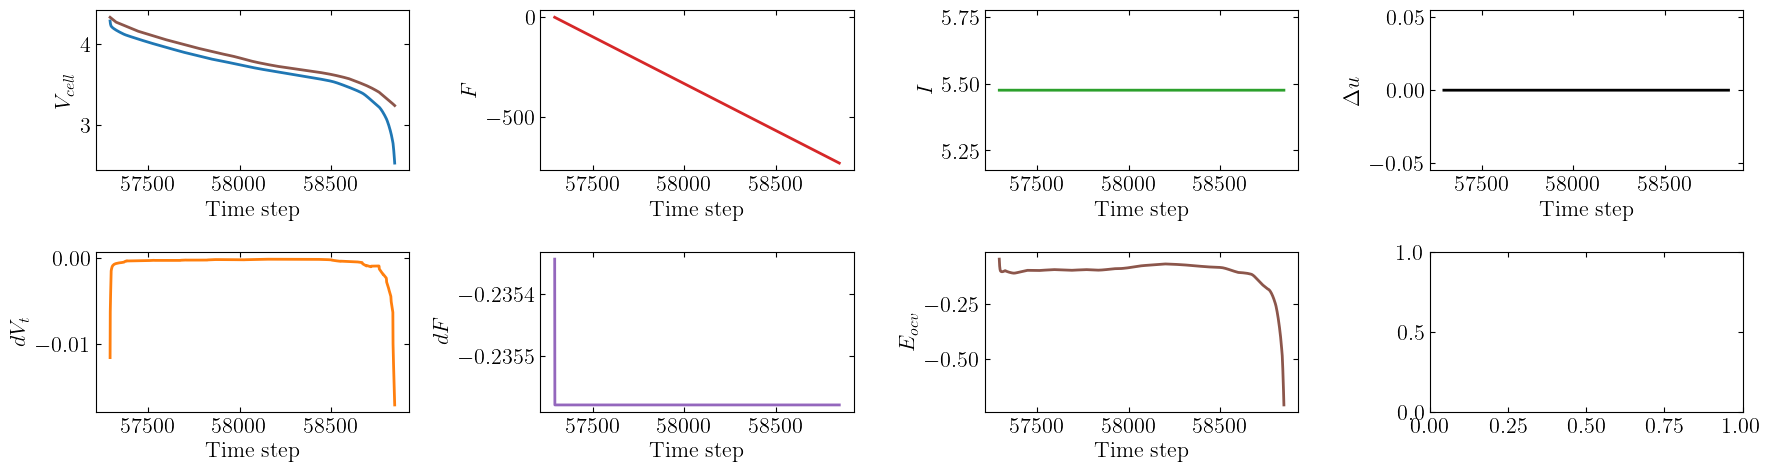

In [128]:

plot_idx = data['trajectory'] == 6
f, ax = plt.subplots(2, 4, figsize=(18, 5))
ax[0, 0].plot(data['V_t'][plot_idx], '-', color = colors[0], lw = 2)
ax[0, 0].set_xlabel('Time step')
ax[0, 0].set_ylabel('$V_{cell}$')
ax[0, 1].plot(data['Rx'][plot_idx], lw = 2,color = colors[1])
ax[0, 1].set_xlabel('Time step')
ax[0, 1].set_ylabel('$F$')
ax[0, 2].plot(data['I'][plot_idx], lw = 2,color = colors[2])
ax[0, 2].set_xlabel('Time step')
ax[0, 2].set_ylabel('$I$')
ax[0, 3].plot(data['u'][plot_idx], lw = 2,color = colors[3])
ax[0, 3].set_xlabel('Time step')
ax[0, 3].set_ylabel(r'$\Delta u$')
ax[1, 0].plot(data['dV_t'][plot_idx], lw = 2,color = colors[4])
ax[1, 0].set_xlabel('Time step')
ax[1, 0].set_ylabel('$dV_t$')
ax[1, 1].plot(data['dRx'][plot_idx], lw = 2,color = colors[5])
ax[1, 1].set_xlabel('Time step')
ax[1, 1].set_ylabel('$dF$')
ax[0, 0].plot(data['ocv'][plot_idx], lw = 2,color = colors[6])
ax[1,2].plot(data['eta'][plot_idx], lw = 2,color = colors[6])
ax[1, 2].set_xlabel('Time step')
ax[1, 2].set_ylabel('$E_{ocv}$')


plt.tight_layout()
plt.show()

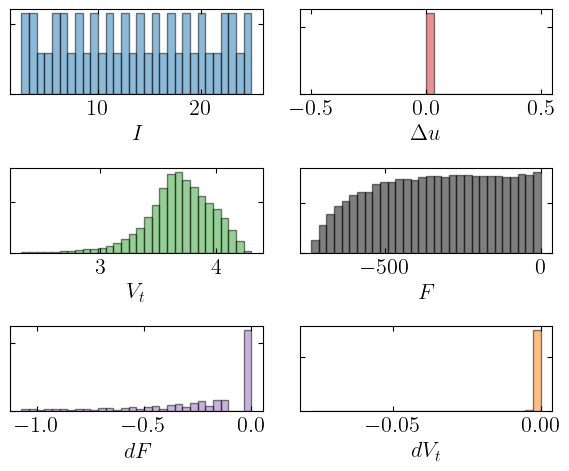

In [129]:
f, ax = plt.subplots(3,2,figsize=(6, 5))

ax[0,0].hist(np.unique(data['I']), bins=30, color=colors[0], alpha=0.5,edgecolor='black',density=True)
ax[0,1].hist(np.unique(data['u']) , bins=30, color=colors[1], alpha=0.5,edgecolor='black',density=True)
ax[1,0].hist(data['V_t'], bins=30, color=colors[2], alpha=0.5,edgecolor='black',density=True)
ax[1,1].hist(np.unique(data['Rx']), bins=30, color=colors[3], alpha=0.5,edgecolor='black',density=True)
ax[2,0].hist((data['dRx']), bins=30, color=colors[5], alpha=0.5,edgecolor='black',density=True)
ax[2,1].hist(data['dV_t'], bins=30, color=colors[4], alpha=0.5,edgecolor='black',density=True)
ax[0,0].set_xlabel('$I$')
ax[0,1].set_xlabel(r'$\Delta u$')
ax[1,0].set_xlabel('$V_t$')
ax[1,1].set_xlabel('$F$')
ax[2,0].set_xlabel('$dF$')
ax[2,1].set_xlabel('$dV_t$')
for a in ax.flat:
    a.set_yticklabels([])
plt.tight_layout()
plt.show()

# Normalizing data

### Characteristics that should be preserved after normalization?


- $\Delta u$: It should primarily be compression, so have a negative sign. 
    - $\Delta u / L$ gives a fractional compression 
- $I$: The sign of it should reflect if we have charge/discharge
    - Maybe just a `standard` normalization on this? 
- $V$: It should always be positive
    - Maybe just a `min-max` normalization on this? 
- $F$: The sign of it should in some way reflect the sign of $\Delta u$. Especially in the cases with low swelling. 
    - Maybe just a `standard` normalization on this? 

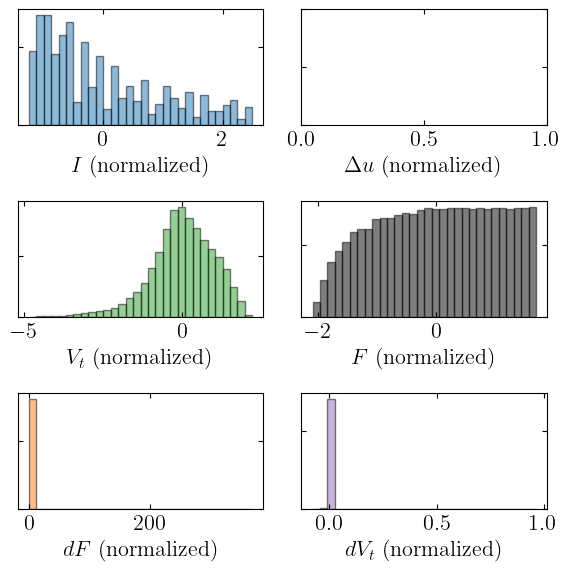

In [ ]:
stats = {}

def compute_stats(x, name):
    # if name == 'R':
    #     stats[name] = (np.min(x), np.max(x))
    # else:
    stats[name] = (np.mean(x), np.std(x))
    return stats[name]

stats['I'] = compute_stats(data['I'], 'I')
stats['V_t'] = compute_stats(data['V_t'], 'V_t')
stats['u_par'] = compute_stats(data['u_par'], 'u_par')
stats['Rx'] = compute_stats(data['Rx'], 'Rx')
stats['dV_t'] = compute_stats(data['dV_t'], 'dV_t')
stats['dRx'] = compute_stats(data['dRx'], 'dRx')

def normalize(x, name, stats = stats):
    #if name == 'R':
    return (x - stats[name][0]) / stats[name][1]
    #else: 
    #    return (x - stats[name][0]) / (stats[name][1] - stats[name][0])

def denormalize(x, name, stats=stats):
    #if name == 'R':
    return x * stats[name][1] + stats[name][0]
    #else:   
    #    return x * (stats[name][1] - stats[name][0]) + stats[name][0]
    
data['I_norm'] = normalize(data['I'], 'I')
data['V_t_norm'] = normalize(data['V_t'], 'V_t')
data['u_par_norm'] = normalize(data['u_par'], 'u_par')
data['Rx_norm'] = normalize(data['Rx'], 'Rx')

f, ax = plt.subplots(3,2,figsize=(6, 6))
ax[0,0].hist(data['I_norm'], bins=30, color=colors[0], alpha=0.5,edgecolor='black',density=True)
ax[1,0].hist(data['V_t_norm'], bins=30, color=colors[2], alpha=0.5,edgecolor='black',density=True)
ax[1,1].hist(data['Rx_norm'], bins=30, color=colors[3], alpha=0.5,edgecolor='black',density=True)
ax[2,0].hist(data['dRx'], bins=30, color=colors[4], alpha=0.5,edgecolor='black',density=True)
ax[2,1].hist(data['dV_t'], bins=30, color=colors[5], alpha=0.5,edgecolor='black',density=True)
ax[0,0].set_xlabel('$I$ (normalized)')
ax[0,1].set_xlabel(r'$\Delta u$ (normalized)')
ax[1,0].set_xlabel('$V_t$ (normalized)')
ax[1,1].set_xlabel('$F$ (normalized)')
ax[2,0].set_xlabel('$dF$ (normalized)')
ax[2,1].set_xlabel('$dV_t$ (normalized)')
for a in ax.flat:
    a.set_yticklabels([])
plt.tight_layout()
plt.show()

# Splitting data

- The targets $y_{k+1}$ have to be extracted
    - Ensuring that the targets are within the same trajectory
    - One can check by using a `valid = (traj_id[:-1] == traj_id[1:])`
- Next, they have to matched such that each training-pair has the following form $$(y_{k+1})\sim(y_k,x_k)$$

In [ ]:
# N_trajs = len(data['trajectory'].unique())


# test_inds = data['trajectory'] >= int(N_trajs * 0.8)

# print(test_inds.sum(), 'test samples')

# X = np.zeros((len(data) +1, 4))
# y = np.zeros((len(data) + 1,2))
# print(len(data[['V_t_norm']].values))
# traj_len0 = 0

# for traj_ids in range(0, N_trajs):
#     traj_len1 = traj_len0 + len(data[data['trajectory'] == traj_ids]) - 1
#     X[traj_len0:traj_len1,...] = data[['V_t_norm','Rx_norm','I_norm','u_par_norm']][data['trajectory'] == traj_ids].values[:-1]
#     y[traj_len0:traj_len1,...] = data[['V_t_norm','Rx_norm']][data['trajectory'] == traj_ids].values[1:]

#     traj_len0 = traj_len1
# print(X[:3])
# print(y[:2])

In [ ]:
N_trajs = len(data['trajectory'].unique())


test_inds = data['trajectory'] >= int(N_trajs * 0.8)

print(test_inds.sum(), 'test samples')

X = np.zeros((len(data) +1, 4))
y = np.zeros((len(data) + 1,2))
print(len(data[['V_t_norm']].values))
traj_len0 = 0

for traj_ids in range(0, N_trajs):
    print(f'{traj_ids} \t {traj_len0} \t {traj_len0 + len(data[data['trajectory'] == traj_ids])} \t {len(data[data['trajectory'] == traj_ids-1]) - len(data[data['trajectory'] == traj_ids])}')
    traj_len1 = traj_len0 + len(data[data['trajectory'] == traj_ids]) 
    X[traj_len0:traj_len1,...] = data[['V_t_norm','Rx_norm','I_norm','u_par_norm']][data['trajectory'] == traj_ids].values
    y[traj_len0:traj_len1 - 1,0] = np.diff(data['V_t'][data['trajectory'] == traj_ids].values) / DT
    y[traj_len1,0] = np.diff(data['V_t'][data['trajectory'] == traj_ids].values)[-1] / DT

    y[traj_len0:traj_len1-1,1] = np.diff(data['Rx'][data['trajectory'] == traj_ids].values) / DT
    y[traj_len1,1] = np.diff(data['Rx'][data['trajectory'] == traj_ids].values)[-1] / DT

    traj_len0 = traj_len1
y[:,0] = normalize(y[:,0], 'dV_t', stats)
y[:,1] = normalize(y[:,1], 'dRx', stats)
print(X.shape)

5418 test samples
61573
0 	 0 	 1801 	 -1801
1 	 1801 	 3602 	 0
2 	 3602 	 9005 	 -3602
3 	 9005 	 10806 	 3602
4 	 10806 	 14408 	 -1801
5 	 14408 	 17854 	 156
6 	 17854 	 19409 	 1891
7 	 19409 	 22253 	 -1289
8 	 22253 	 24861 	 236
9 	 24861 	 27275 	 194
10 	 27275 	 28394 	 1295
11 	 28394 	 30482 	 -969
12 	 30482 	 32438 	 132
13 	 32438 	 34280 	 114
14 	 34280 	 36012 	 110
15 	 36012 	 37650 	 94
16 	 37650 	 38426 	 862
17 	 38426 	 39902 	 -700
18 	 39902 	 41304 	 74
19 	 41304 	 42640 	 66
20 	 42640 	 43920 	 56
21 	 43920 	 44532 	 668
22 	 44532 	 45704 	 -560
23 	 45704 	 46267 	 609
24 	 46267 	 47887 	 -1057
25 	 47887 	 48406 	 1101
26 	 48406 	 49404 	 -479
27 	 49404 	 50368 	 34
28 	 50368 	 51294 	 38
29 	 51294 	 51741 	 479
30 	 51741 	 52609 	 -421
31 	 52609 	 53445 	 32
32 	 53445 	 54255 	 26
33 	 54255 	 55039 	 26
34 	 55039 	 55419 	 404
35 	 55419 	 56155 	 -356
36 	 56155 	 56869 	 22
37 	 56869 	 57561 	 22
38 	 57561 	 58235 	 18
39 	 58235 	 58

In [ ]:
print(f"Number of trajectories: {N_trajs}")

Number of trajectories: 46


In [ ]:

x_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

split = (data['trajectory']<=int(N_trajs *0.8)).sum()

def _split_flat(arr, split = split):
    return arr[:split], arr[split:]   # Same as reshape(B * T, C)    # (B*T, 4)

x_train, x_test = _split_flat(x_tensor); y_train, y_test = _split_flat(y_tensor)

print(f'Number of trajectories in train: {int(N_trajs * 0.8)} out of {N_trajs}')

print(f'X shape {x_tensor.shape}\ty shape {y_tensor.shape}\nX-train shape: {x_train.shape}\ty-train shape: {y_train.shape}\nX-test shape: {x_test.shape}\ty-test shape: {y_test.shape}')

df_train = data[data['trajectory'] <= int(N_trajs * 0.8)]
df_test = data[data['trajectory'] > int(N_trajs * 0.8)]

train_loader_flat = DataLoader(TensorDataset(x_train, y_train), batch_size=256 , shuffle=False)

Number of trajectories in train: 36 out of 46
X shape torch.Size([61574, 4])	y shape torch.Size([61574, 2])
X-train shape: torch.Size([56869, 4])	y-train shape: torch.Size([56869, 2])
X-test shape: torch.Size([4705, 4])	y-test shape: torch.Size([4705, 2])


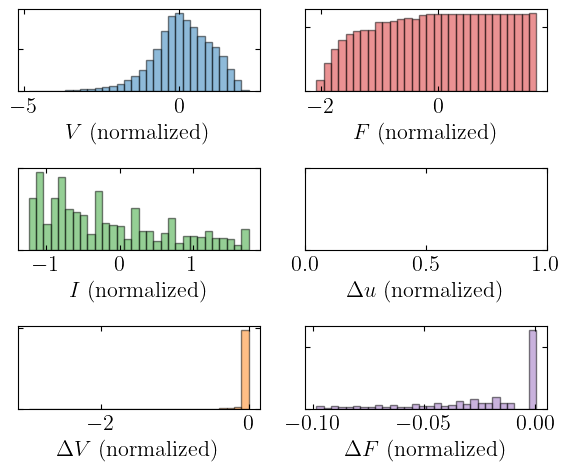

In [ ]:
# plotting histograms of the training data
f, ax = plt.subplots(3,2,figsize=(6, 5))
ax[0,0].hist(x_train[:,0].numpy(), bins=30, color=colors[0], alpha=0.5,edgecolor='black',density=True)
ax[0,1].hist(x_train[:,1].numpy(), bins=30, color=colors[1], alpha=0.5,edgecolor='black',density=True)    
ax[1,0].hist(x_train[:,2].numpy(), bins=30, color=colors[2], alpha=0.5,edgecolor='black',density=True)
ax[2,0].hist(y_train[:,0].numpy(), bins=30, color=colors[4], alpha=0.5,edgecolor='black',density=True)
ax[2,1].hist(y_train[:,1].numpy(), bins=30, color=colors[5], alpha=0.5,edgecolor='black',density=True)
ax[0,0].set_xlabel('$V  $ (normalized)')
ax[0,1].set_xlabel('$F$ (normalized)')
ax[1,0].set_xlabel('$I$ (normalized)')
ax[1,1].set_xlabel(r'$\Delta u$ (normalized)')
ax[2,0].set_xlabel(r'$\Delta V$ (normalized)')
ax[2,1].set_xlabel(r'$\Delta F$ (normalized)')
for a in ax.flat:
    a.set_yticklabels([])
plt.tight_layout()
plt.show()



# Defining model

Inputs: $I_t$, $\Delta u_t$, $V_t$, $F_t$

Outputs $\dot{V}_t$, $\dot{F}_t$

Employing a NODE setup, with the state variable $\xi = [V,F]$, we get $$\dot{\xi}=f_{NN}(I_t,\Delta u_t,\xi)\Rightarrow \xi(t) = \int_0^tf_{NN}(I_t,\Delta u_t,\xi)\,\mathrm{d}t$$

In [ ]:
''' Mk 1 '''
import torch.nn.functional as FUNC


class Net(nn.Module):
    def __init__(self, input_size=4, hidden_size=256): 
        super(Net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 2)   # output size is 2 for (V_cell, F)
        )
    
    # def forward(self, x,yk):
    #     X = torch.cat((x,yk), dim=1)
    #     yk1 = self.net(X)
    #     return yk1
    def forward(self, input, PE = False):
        V_dot_raw = self.net(input)[:,0:1]
        F_dot_raw = self.net(input)[:,1:2]

        return V_dot_raw, F_dot_raw
    
model = Net()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
try: 
    print(summary(model, input_data=x_train[:2]))
except Exception as e:
    print(f"Error in model summary: {e}")

Layer (type:depth-idx)                   Output Shape              Param #
Net                                      [2, 1]                    --
├─Sequential: 1-1                        [2, 2]                    --
│    └─Linear: 2-1                       [2, 256]                  1,280
│    └─ReLU: 2-2                         [2, 256]                  --
│    └─Linear: 2-3                       [2, 256]                  65,792
│    └─ReLU: 2-4                         [2, 256]                  --
│    └─Linear: 2-5                       [2, 2]                    514
├─Sequential: 1-2                        [2, 2]                    (recursive)
│    └─Linear: 2-6                       [2, 256]                  (recursive)
│    └─ReLU: 2-7                         [2, 256]                  --
│    └─Linear: 2-8                       [2, 256]                  (recursive)
│    └─ReLU: 2-9                         [2, 256]                  --
│    └─Linear: 2-10                      [2, 2]   

# Training
Since we only have values for $V_t$ and $F_t$, we need to add a torch-compatible integrator within the training procedure. For starters, we use the simple Euler forward, yielding the following loss $$\mathcal{L} = \|\xi_t-f_{NN}(x_t)\Delta t\|^2_2\quad x_t = [I_t,\Delta u_t].$$
After training, the model could in principle be used in your favorite integrator. 

In [ ]:
def next_step(dy, X, dt=DT, stats=stats):
    y = X[:, :2]

    V = denormalize(y[:,0], 'V_t', stats)
    F = denormalize(y[:,1], 'Rx', stats)

    dV = denormalize(dy[:,0], 'dV_t', stats)
    dF = denormalize(dy[:,1], 'dRx', stats)

    V1 = V + dV * dt
    F1 = F + dF * dt

    y1 = torch.zeros_like(y)
    y1[:,0] = normalize(V1, 'V_t', stats)
    y1[:,1] = normalize(F1, 'Rx', stats)

    return y1

In [ ]:
# def next_step_rk4(model, X, dt=DT, stats=stats):
#     y = X[:, :2]          # state
#     extra = X[:, 2:]      # other features (must be preserved)

#     def to_phys(y):
#         V = denormalize(y[:, 0], 'V_t', stats)
#         F = denormalize(y[:, 1], 'Rx', stats)
#         return torch.stack([V, F], dim=1)

#     def to_norm(Y):
#         y_norm = torch.zeros_like(Y)
#         y_norm[:, 0] = normalize(Y[:, 0], 'V_t', stats)
#         y_norm[:, 1] = normalize(Y[:, 1], 'Rx', stats)
#         return y_norm

#     def f(Y_phys):
#         Y_norm = to_norm(Y_phys)

#         X_full = torch.cat([Y_norm, extra], dim=1)

#         dy = model(X_full)

#         dV = denormalize(dy[:, 0], 'dV_t', stats)
#         dF = denormalize(dy[:, 1], 'dRx', stats)
#         return torch.stack([dV, dF], dim=1)

#     Y0 = to_phys(y)

#     k1 = f(Y0)
#     k2 = f(Y0 + 0.5 * dt * k1)
#     k3 = f(Y0 + 0.5 * dt * k2)
#     k4 = f(Y0 + dt * k3)

#     Y1 = Y0 + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

#     y_next = to_norm(Y1)

#     return torch.cat([y_next, extra], dim=1)

# def step(model, x, dt):
#     return next_step_rk4(model, x, dt)

# def next_step_stable(model, x, dt, substeps=5):
#     dt_small = dt / substeps
#     for _ in range(substeps):
#         x = step(model, x, dt_small)
#     return x
    

def training(epochs=30):
    history = {"loss": [], "d_loss": [], "p_loss": [], "time per ep": []}
    tot_time = 0.0
    for ep in range(epochs):
        model.train()
        tot_ep_loss = 0.0
        d_ep_loss = 0.0
        start_t = time.perf_counter()
        for x_b, y_b in train_loader_flat:
            # print('batch shapes:', x_b.shape, y_b.shape, mask_b.shape)
            #y_pred = next_step_stable(model, x_b, DT, substeps=5)[:,:2]
            dy = model(x_b)
            d_loss = nn.MSELoss()(dy, y_b)
            tot_loss = d_loss
            # print('pred shapes:', pred.shape)
            optimizer.zero_grad()
            tot_loss.backward()
            optimizer.step()
            tot_ep_loss += d_loss.item()
            d_ep_loss += d_loss.item()
        tot_last = tot_ep_loss / len(train_loader_flat)  # Average loss per batch
        d_last = d_ep_loss / len(train_loader_flat)
        end_t = time.perf_counter()

        history["loss"].append(tot_last)
        history["d_loss"].append(d_last)
        history["time per ep"].append(end_t - start_t)
        tot_time += end_t - start_t
        if ep == 0:
            print(f'ETA: {(end_t - start_t) * epochs / 60:.2f} min')

        if tot_time > 2*60:
            print("Early stopping: Total training time exceeded 3 minutes.")
            break
        print(f"Epoch {ep+1} | loss {tot_last:.3e} | time {end_t - start_t:.2f}s")

    return history

In [ ]:
history = training(epochs=100)

AttributeError: 'tuple' object has no attribute 'size'

0.0009981504100491484


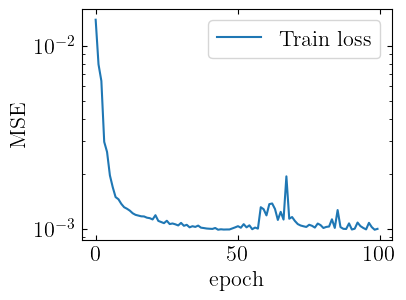

In [ ]:
#model_name = 'Second_PENN_ReLU'
#PENN_exp_log.exp_log(model, history, current = currents,name=model_name, d_loss_type = 'mse')
#torch.save(model.state_dict(), f'models/{model_name}_{currents}.pth')
print(history['loss'][-1])
fig, (ax1) = plt.subplots(1, 1, figsize=(4, 3))
ax1.semilogy(history["loss"], label="Train loss")
# ax1.set_yscale("log")
ax1.set_xlabel("epoch")
ax1.set_ylabel("MSE")
ax1.legend()

In [ ]:
from scipy.interpolate import interp1d

def denorm_y(y, stats=stats):
    V = denormalize(y[:,0], 'V_t', stats)
    F = denormalize(y[:,1], 'Rx', stats)
    return np.stack([V, F], axis=1)

def rollout(model, x_init, steps=100):
    dt = DT
    traj = np.zeros((steps, 2))
    traj_dy = np.zeros((steps, 2))
    x = x_init.clone()
    traj[0] = x[0, :2].numpy()
    model.eval()
    for t in range(1,steps):
        with torch.no_grad():

            x = next_step_rk4(model, x, dt, stats)
            traj[t] = x[0, :2].numpy()
            dy = model(x)[:,:2]
            traj_dy[t] = dy[0].numpy()
    return traj,traj_dy

rollout_steps = 210

traj,traj_dy = rollout(model, x_test[:1], steps=rollout_steps)

plt.plot(traj[:,0], label='Predicted V', color=colors[0])
plt.plot(x_test[:rollout_steps,0].numpy(), label='True V', color=colors[1],ls = '--')
plt.xlabel('Time step')
plt.ylabel('$V_{cell}$ (normalized)')
plt.legend()


NameError: name 'next_step_rk4' is not defined

In [ ]:
def rollout(model,x_init,steps=100):
    traj = np.zeros((steps, 2))
    traj_dy = np.zeros((steps, 2))
    x = x_init.clone()
    y0 = x[:2].numpy()
    print(y0)
    traj[0] = y0
    model.eval()
    for t in range(1,steps):
        with torch.no_grad():
            dy = model(x)
            V1 = denormalize(x[0], 'V_t', stats) + denormalize(dy[0],'dV_t') * DT
            F1 = denormalize(x[1], 'Rx', stats) + denormalize(dy[1],'dRx') * DT
            x[0] = normalize(V1, 'V_t', stats)
            x[1] = normalize(F1, 'Rx', stats)

            traj[t] = x[:2].numpy()
            traj_dy[t] = dy.numpy()
    return traj,traj_dy

traj,traj_dy = rollout(model, x_test[:1][0], steps=10)
plt.plot(traj[:,1], label='Predicted dV', color=colors[0])
plt.plot(x_test[:10,1].numpy(), label='True dV', color=colors[1])

[ 0.7553891 -2.1245954]


IndexError: too many indices for tensor of dimension 1

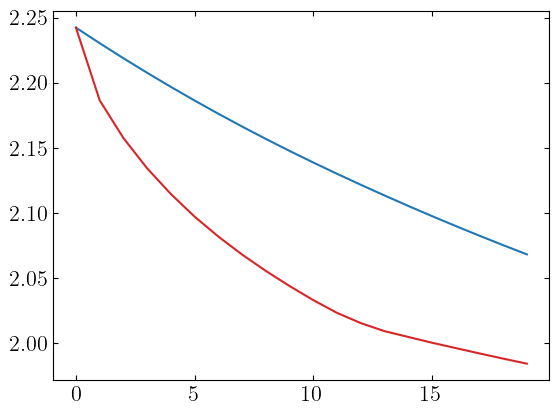

In [ ]:
def rollout_backward(model, x_init, steps=100, max_iter=10, dt = DT, stats=stats):
    traj = np.zeros((steps, 2))
    traj_dy = np.zeros((steps, 2))
    
    x = x_init.clone()
    traj[0] = x[:2].numpy()

    model.eval()

    for t in range(1, steps):
        x_old = x.clone()
        x_new = x.clone()  # initial guess

        for _ in range(max_iter):
            with torch.no_grad():
                dy = model(x_new)

                V1 = denormalize(x_old[0], 'V_t', stats) + denormalize(dy[0], 'dV_t') * dt
                F1 = denormalize(x_old[1], 'Rx', stats) + denormalize(dy[1], 'dRx') * dt

                x_new[0] = normalize(V1, 'V_t', stats)
                x_new[1] = normalize(F1, 'Rx', stats)

        x = x_new.clone()

        traj[t] = x[:2].numpy()
        traj_dy[t] = dy.numpy()

    return traj, traj_dy


steps = 20
traj, traj_dy = rollout_backward(model, x_train[:1][0], steps=steps, max_iter=30)
plt.plot(traj[:,0], label='Predicted V', color=colors[0])
plt.plot(x_train[:steps,0].numpy(), label='True V', color=colors[1])